# Morality analysis by party

Full-corpus LLM moral-civility labels (`gemma4:12b`, baseline prompt, see
`measurement/morality_measurement.md`), by party, in the state's ±1yr window around its
AfD entry. Same construction as `analysis/impoliteness_analysis.ipynb`.

The label has three classes (`neutral`, `moralisch`, `unmoralisch`), so every plot is
drawn once per non-neutral class.

- **Sachsen**: 2013-10 to 2015-09, spans the 2014-08-31 election (AfD enters, FDP and NPD exit).
- **Bayern**: no morality run yet. Set `STATE = "by"` once `morality_full_by_gemma4-12b_baseline.csv` exists.

In [1]:
import os

if "DATA_ROOT" not in os.environ:
    try:
        from dotenv import load_dotenv, find_dotenv
        load_dotenv(find_dotenv())
    except ImportError:
        pass
DATA_ROOT = os.environ.get("DATA_ROOT", "")

print("DATA_ROOT:", DATA_ROOT)
assert DATA_ROOT and os.path.isdir(DATA_ROOT), f"DATA_ROOT not set or missing: {DATA_ROOT!r}"

DATA_ROOT: /Users/anna/Library/CloudStorage/GoogleDrive-anle.werner.01@gmail.com/My Drive/my_projects/M.A. Parliament/Code and Data/data


In [2]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

_cwd = Path(".").resolve()
_repo = _cwd if (_cwd / "utils" / "colors.py").exists() else _cwd.parent
if str(_repo) not in sys.path:
    sys.path.insert(0, str(_repo))
from utils.colors import AFFILIATION_COLORS, GOLD, NAVY

MEAS = Path(DATA_ROOT) / "measurement"
PROC = Path(DATA_ROOT) / "processed"

## Moral-civility labels

Output of `measurement/colab_gemma.ipynb` with `CONSTRUCT = "morality"`. As in the
impoliteness file, `segment_idx == -1` rows are speech paragraphs carrying the speaker's
party, `segment_idx >= 0` rows are unattributed `nsc` segments. Only the former are used.
`pre` (presidium), `gov` (government bench) and `oth` are dropped, as in the impoliteness notebook.

In [3]:
STATE = "sn"

STATES = {
    "sn": dict(name="Sachsen",
               parties=["cdu", "spd", "grn", "fdp", "lin", "npd", "afd"],
               entry=pd.Timestamp("2014-09-29")),  # processed/afd_entry_dates.csv
    "by": dict(name="Bayern",
               parties=["csu", "spd", "grn", "fdp", "frw", "afd"],
               entry=pd.Timestamp("2018-11-05")),
}
PARTY_LABELS = {"cdu": "CDU", "csu": "CSU", "spd": "SPD", "grn": "GRÜNE", "fdp": "FDP",
                "lin": "LINKE", "npd": "NPD", "frw": "Freie Wähler", "afd": "AfD"}
LABELS = ["moralisch", "unmoralisch"]
TITLE = "Moral civility (gemma4:12b baseline)"

cfg = STATES[STATE]
PARTIES, AFD_ENTRY, STATE_NAME = cfg["parties"], cfg["entry"], cfg["name"]

mor = pd.read_csv(MEAS / f"morality_full_{STATE}_gemma4-12b_baseline.csv", parse_dates=["date"])
print(f"{len(mor):,} rows total, {mor['moral_civility'].isna().sum()} unparsed")

speech = mor[(mor["segment_idx"] == -1) & (mor["affiliation"].isin(PARTIES))].copy()
print(f"{len(speech):,} speech paragraphs across {speech['affiliation'].nunique()} parties")

(pd.crosstab(speech["affiliation"], speech["moral_civility"], normalize="index")
   .reindex(PARTIES).mul(100).round(1)
   .assign(n=speech["affiliation"].value_counts()))

67,114 rows total, 0 unparsed
36,885 speech paragraphs across 7 parties


moral_civility,moralisch,neutral,unmoralisch,n
affiliation,,,,
cdu,11.2,87.6,1.2,8978
spd,13.1,85.6,1.3,5534
grn,11.5,87.2,1.3,5916
fdp,10.5,88.4,1.1,3045
lin,11.4,86.6,2.0,8287
npd,3.8,80.7,15.5,2695
afd,8.5,88.4,3.2,2430


## Class shares by party

Left: all three classes stacked to 100%. Right: the two non-neutral classes on their own
scale, since `neutral` (~87%) squeezes them to slivers on the left.

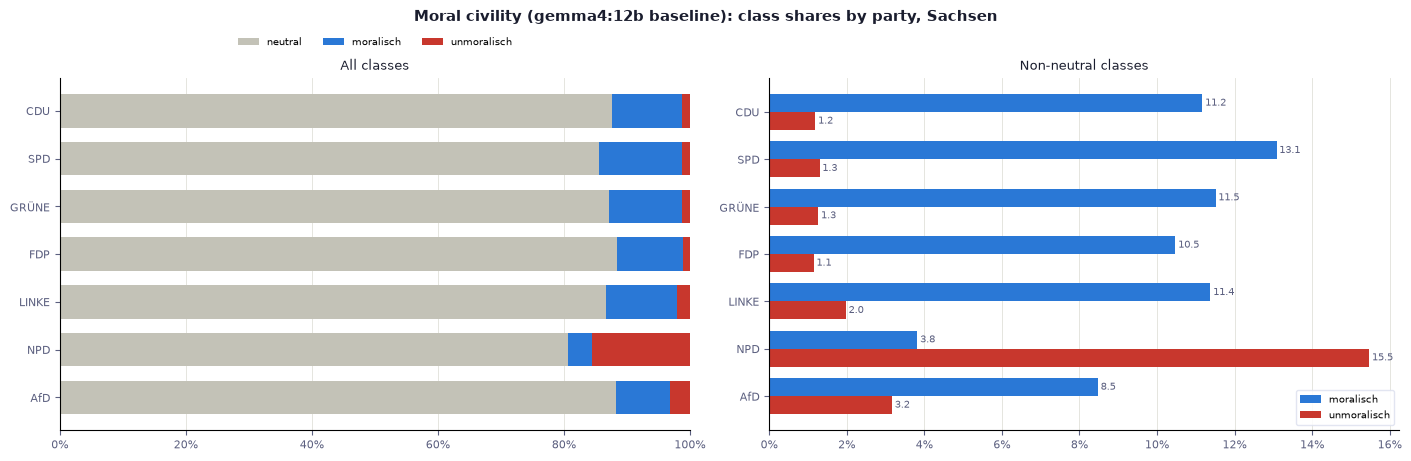

In [4]:
CLASS_ORDER = ["neutral", "moralisch", "unmoralisch"]
CLASS_COLORS = {"neutral": "#C3C2B7", "moralisch": NAVY, "unmoralisch": "#C8372D"}

class_share = (pd.crosstab(speech["affiliation"], speech["moral_civility"], normalize="index")
                 .reindex(index=PARTIES, columns=CLASS_ORDER, fill_value=0) * 100)
ylabels = [PARTY_LABELS[p] for p in PARTIES]
y = np.arange(len(PARTIES))

fig, (ax_all, ax_moral) = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
fig.suptitle(f"{TITLE}: class shares by party, {STATE_NAME}", fontsize=11, fontweight="bold", color="#1A1D2E")

left = np.zeros(len(PARTIES))
for cls in CLASS_ORDER:
    ax_all.barh(y, class_share[cls], left=left, color=CLASS_COLORS[cls], label=cls, height=0.7)
    left += class_share[cls].to_numpy()
ax_all.set_title("All classes", fontsize=9.5, color="#1A1D2E")
ax_all.set_xlim(0, 100)
ax_all.legend(fontsize=7.5, loc="lower center", bbox_to_anchor=(0.5, 1.06), ncol=3, frameon=False)

h = 0.38
for offset, cls in [(-h / 2, "moralisch"), (h / 2, "unmoralisch")]:
    bars = ax_moral.barh(y + offset, class_share[cls], height=h, color=CLASS_COLORS[cls], label=cls)
    ax_moral.bar_label(bars, fmt="%.1f", fontsize=7, padding=2, color="#5C6080")
ax_moral.set_title("Non-neutral classes", fontsize=9.5, color="#1A1D2E")
ax_moral.legend(fontsize=7.5, framealpha=0.85, edgecolor="#DDE1EF", loc="lower right")

for ax in (ax_all, ax_moral):
    ax.set_yticks(y, ylabels)
    ax.invert_yaxis()
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8, colors="#5C6080")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.grid(axis="x", color="#E1E0D9", linewidth=0.6)
    ax.set_axisbelow(True)

fig.savefig(PROC / f"plot_morality_classes_by_party_{STATE}.pdf", bbox_inches="tight")
fig.savefig(PROC / f"plot_morality_classes_by_party_{STATE}.png", dpi=150, bbox_inches="tight")
plt.show()

## Monthly count and rate by party

- Count: paragraphs with the given label per party per month.
- Rate: that party's own share of paragraphs with the label that month (%).

Recess months are reindexed to zero-rows so the centred rolling window runs on calendar
time. The rolling mean is blanked outside each party's first and last active month
(AfD enters, FDP/NPD exit mid-window in Sachsen), see the impoliteness notebook for why.

In [5]:
def label_by_party(df, key, label, full_index=None):
    """Per-party count and own-rate (%) of `label`, grouped by `key` (month/quarter/date)."""
    n = (df.groupby([key, "affiliation"]).size()
           .unstack("affiliation", fill_value=0)
           .reindex(columns=PARTIES, fill_value=0).sort_index())
    if full_index is not None:
        n = n.reindex(full_index, fill_value=0)
    cnt = (df[df["moral_civility"] == label].groupby([key, "affiliation"]).size()
             .unstack("affiliation", fill_value=0)
             .reindex(index=n.index, columns=PARTIES, fill_value=0))
    share = cnt / n * 100  # 0/0 (recess, or party not seated) -> NaN
    if isinstance(n.index, pd.PeriodIndex):
        n.index = cnt.index = share.index = n.index.to_timestamp()
    return n, cnt, share


def _style_axes(ax, entry_date):
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8, colors="#5C6080")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    ax.grid(axis="y", color="#E1E0D9", linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.axvline(entry_date, color=GOLD, linewidth=1.2, linestyle="--", zorder=1)


def plot_by_party(count_data, share_data, label, title, filename, resolution, marker=None):
    fig, (ax_cnt, ax_shr) = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
    fig.suptitle(title, fontsize=11, fontweight="bold", x=0.5, color="#1A1D2E")

    for ax in (ax_cnt, ax_shr):
        _style_axes(ax, AFD_ENTRY)

    for party in PARTIES:
        c, lab = AFFILIATION_COLORS[party], PARTY_LABELS[party]
        ax_cnt.plot(count_data.index, count_data[party],
                    color=c, linewidth=1.4, marker=marker, markersize=2.5, label=lab)
        ax_shr.plot(share_data.index, share_data[party],
                    color=c, linewidth=1.4, marker=marker, markersize=2.5, label=lab)

    ax_cnt.set_ylabel(f"'{label}' paragraphs (count)", fontsize=8.5, color="#5C6080")
    ax_cnt.set_title(f"{resolution} count by party", fontsize=9.5, pad=6, color="#1A1D2E")
    ax_shr.set_ylabel(f"Party's own '{label}' rate (%)", fontsize=8.5, color="#5C6080")
    ax_shr.set_title(f"{resolution} rate by party", fontsize=9.5, pad=6, color="#1A1D2E")
    ax_shr.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0f}%"))
    for ax in (ax_cnt, ax_shr):
        ax.legend(fontsize=7.5, framealpha=0.85, edgecolor="#DDE1EF", loc="upper left", ncol=2)

    fig.savefig(PROC / f"{filename}.pdf", bbox_inches="tight")
    fig.savefig(PROC / f"{filename}.png", dpi=150, bbox_inches="tight")
    plt.show()


ROLL = 3  # centred rolling window, months, same as impoliteness

speech["month"] = speech["date"].dt.to_period("M")
speech["quarter"] = speech["date"].dt.to_period("Q")
full_months = pd.period_range(speech["month"].min(), speech["month"].max(), freq="M")
full_quarters = pd.period_range(speech["quarter"].min(), speech["quarter"].max(), freq="Q")

monthly = {lab: label_by_party(speech, "month", lab, full_months) for lab in LABELS}
monthly_n = monthly[LABELS[0]][0]

first_active = monthly_n.apply(lambda col: col[col > 0].index.min())
last_active = monthly_n.apply(lambda col: col[col > 0].index.max())

print(f"Monthly frame: {monthly_n.index[0].date()} to {monthly_n.index[-1].date()}, "
      f"{len(monthly_n)} months (incl. {(monthly_n.sum(axis=1) == 0).sum()} recess months)")
pd.DataFrame({"first": first_active.dt.strftime("%Y-%m"), "last": last_active.dt.strftime("%Y-%m")})

Monthly frame: 2013-10-01 to 2015-09-01, 24 months (incl. 5 recess months)


,first,last
affiliation,,
cdu,2013-10,2015-09
spd,2013-10,2015-09
grn,2013-10,2015-09
fdp,2013-10,2014-07
lin,2013-10,2015-09
npd,2013-10,2014-07
afd,2014-09,2015-09


Raw monthly values, no smoothing

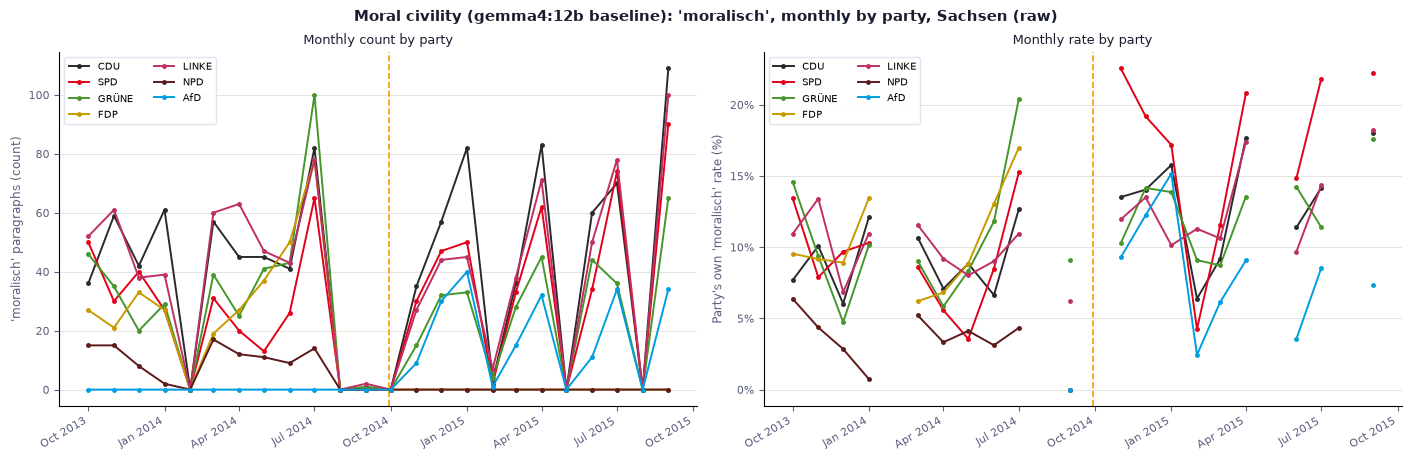

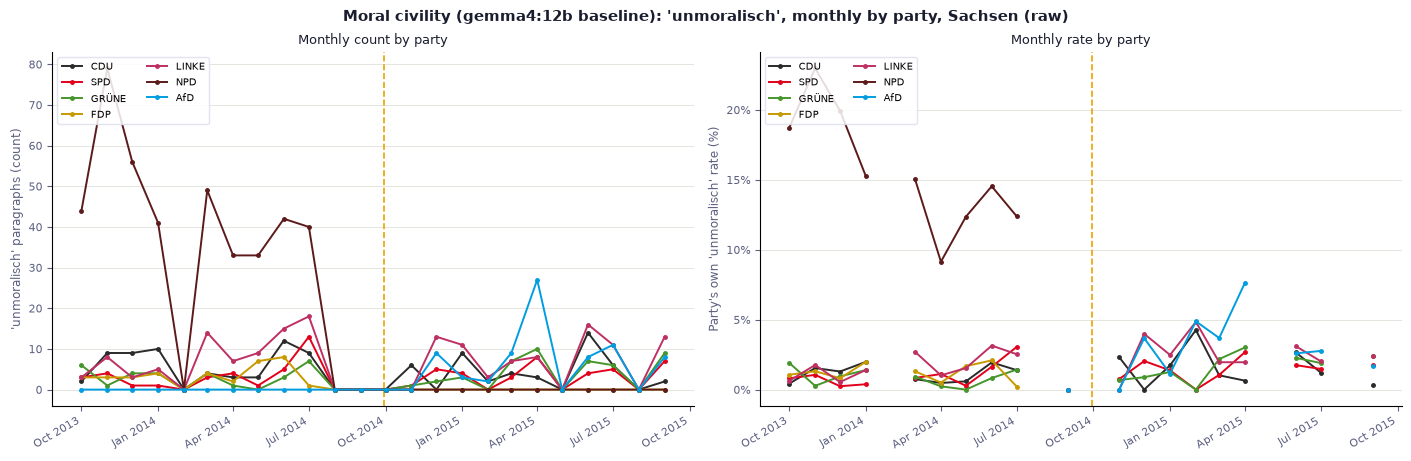

In [6]:
for lab in LABELS:
    _, cnt, share = monthly[lab]
    plot_by_party(cnt, share, lab,
                  title=f"{TITLE}: '{lab}', monthly by party, {STATE_NAME} (raw)",
                  filename=f"plot_morality_{lab}_by_party_{STATE}_raw",
                  resolution="Monthly", marker="o")

3-month centred rolling mean, blanked outside each party's active span

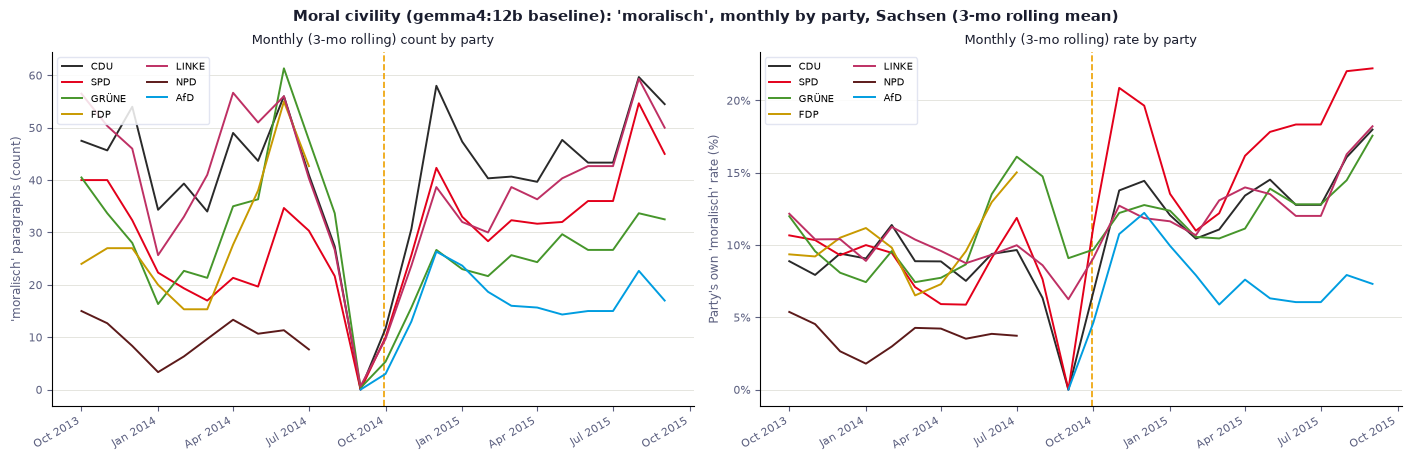

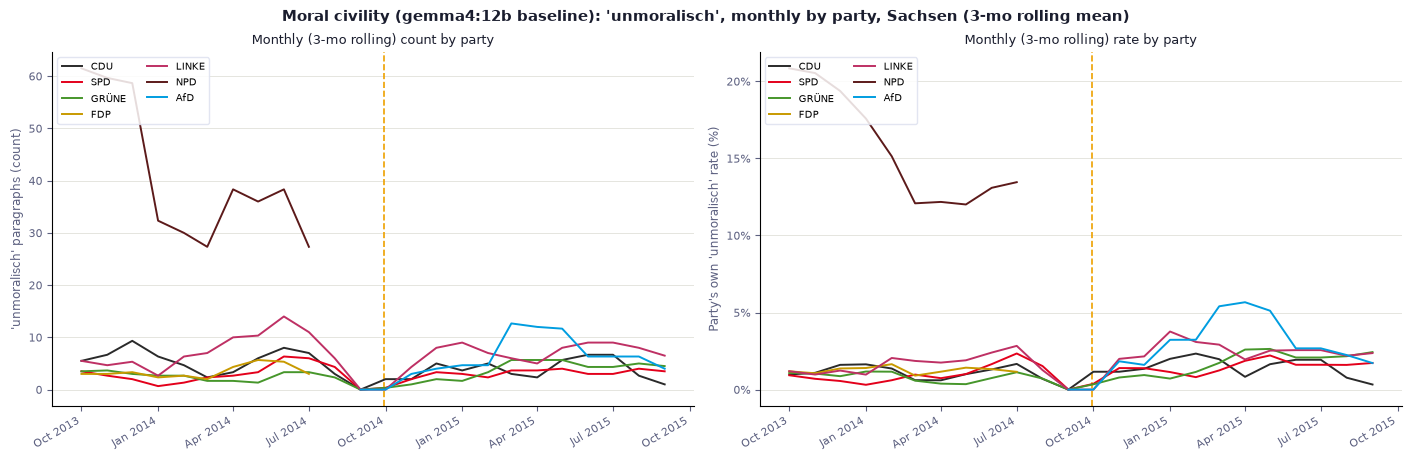

In [7]:
for lab in LABELS:
    _, cnt, share = monthly[lab]
    cnt_roll = cnt.rolling(ROLL, center=True, min_periods=1).mean()
    share_roll = share.rolling(ROLL, center=True, min_periods=1).mean()
    for party in PARTIES:
        _outside = (cnt_roll.index < first_active[party]) | (cnt_roll.index > last_active[party])
        cnt_roll.loc[_outside, party] = np.nan
        share_roll.loc[_outside, party] = np.nan
    plot_by_party(cnt_roll, share_roll, lab,
                  title=f"{TITLE}: '{lab}', monthly by party, {STATE_NAME} ({ROLL}-mo rolling mean)",
                  filename=f"plot_morality_{lab}_by_party_{STATE}_smoothed",
                  resolution=f"Monthly ({ROLL}-mo rolling)")

## Other temporal resolutions

Per session (one point per sitting day, nothing to reindex) and per quarter.

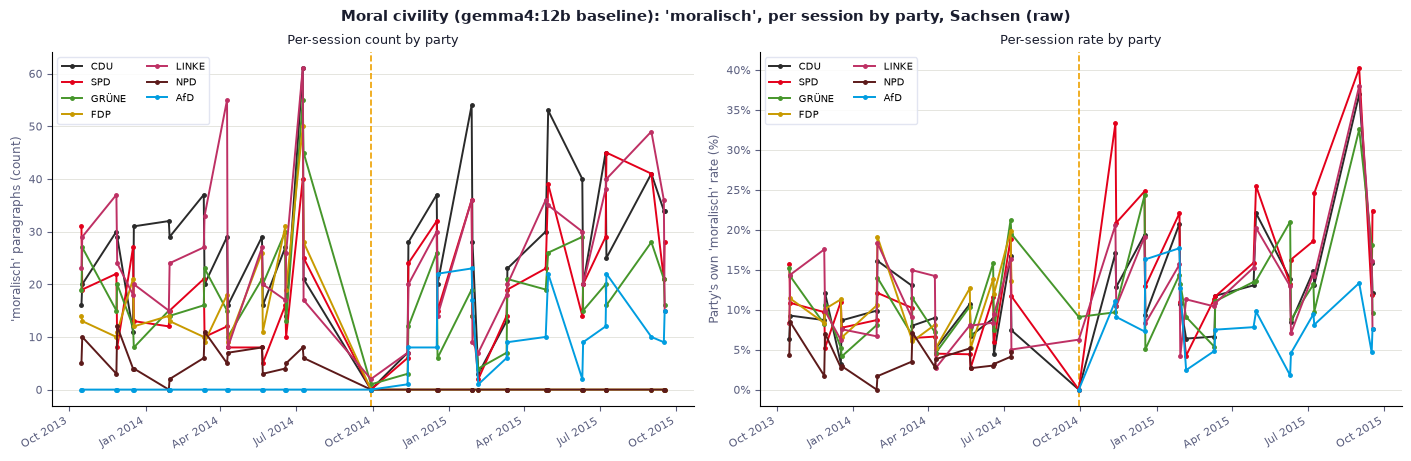

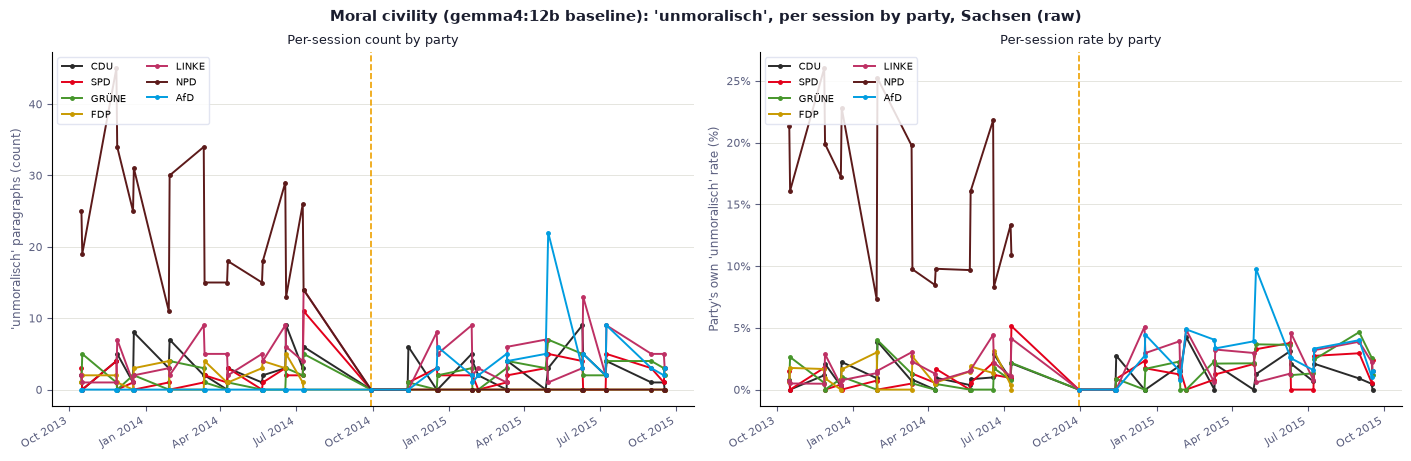

37 distinct session dates


In [8]:
for lab in LABELS:
    session_n, cnt, share = label_by_party(speech, "date", lab)
    plot_by_party(cnt, share, lab,
                  title=f"{TITLE}: '{lab}', per session by party, {STATE_NAME} (raw)",
                  filename=f"plot_morality_{lab}_by_party_{STATE}_session",
                  resolution="Per-session", marker="o")
print(f"{len(session_n)} distinct session dates")

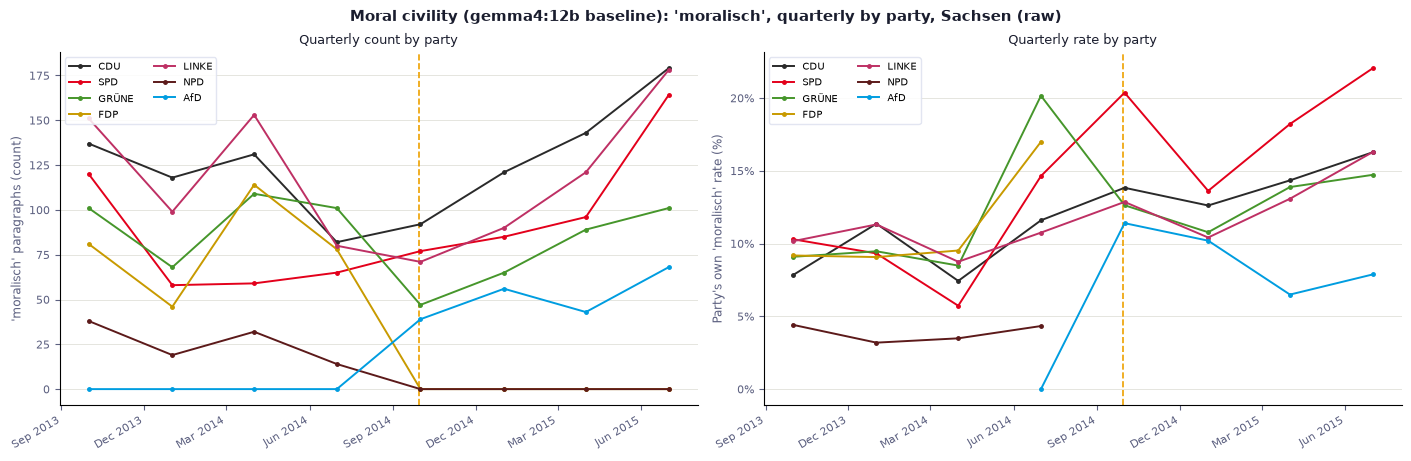

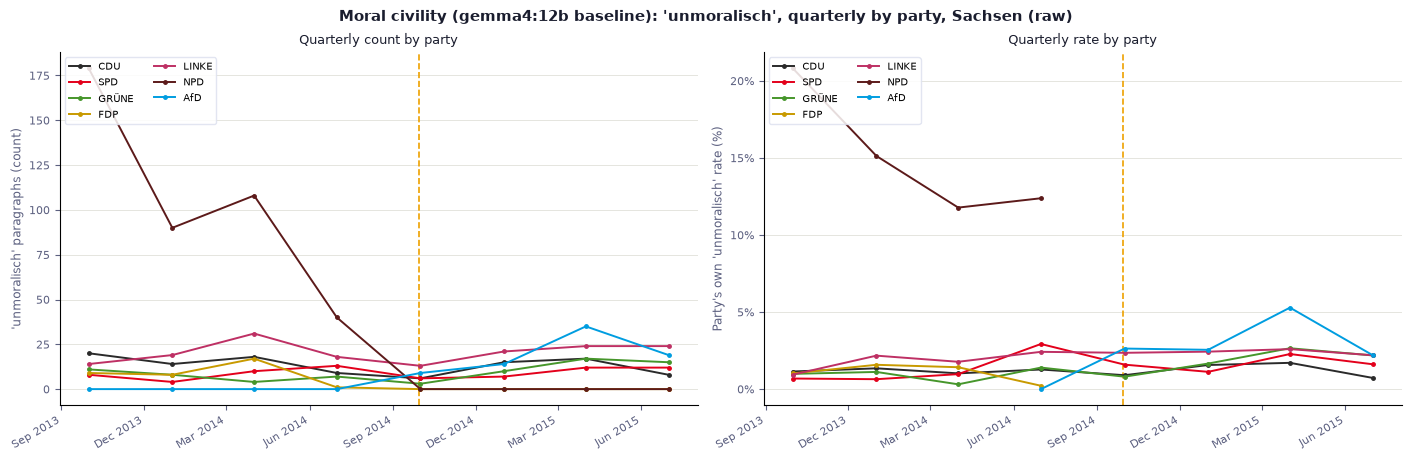

In [9]:
for lab in LABELS:
    _, cnt, share = label_by_party(speech, "quarter", lab, full_quarters)
    plot_by_party(cnt, share, lab,
                  title=f"{TITLE}: '{lab}', quarterly by party, {STATE_NAME} (raw)",
                  filename=f"plot_morality_{lab}_by_party_{STATE}_quarter",
                  resolution="Quarterly", marker="o")

## Examples with Gemma's reason

Random `moralisch` and `unmoralisch` paragraphs, full text, with the model's `reason`.
Set `EXAMPLE_PARTY` to one party code (e.g. `"afd"`) to restrict, `None` for all parties.

In [10]:
N_EXAMPLES = 10
EXAMPLE_PARTY = None
EXAMPLE_SEED = 20260927

def print_examples(df, label):
    print(f"\n{'=' * 90}\n{label}: {len(df)} shown\n{'=' * 90}")
    for _, row in df.iterrows():
        print(f"\nparagraph {row['paragraph_id']} | {PARTY_LABELS[row['affiliation']]} | {row['date'].date()}")
        print(f"Gemma: {row['reason']}")
        print("-" * 60)
        print(row["content"])

pool = speech if EXAMPLE_PARTY is None else speech[speech["affiliation"] == EXAMPLE_PARTY]
for lab in LABELS:
    subset = pool[pool["moral_civility"] == lab]
    sample = subset.sample(min(N_EXAMPLES, len(subset)), random_state=EXAMPLE_SEED).sort_values("date")
    print_examples(sample, f"'{lab}'" + (f", {PARTY_LABELS[EXAMPLE_PARTY]}" if EXAMPLE_PARTY else ""))


'moralisch': 10 shown

paragraph 13752758 | SPD | 2013-10-17
Gemma: Der Begriff 'Humanität' als Grundlage für politische Verantwortung betont die Würde und den Schutz von Mitmenschen.
------------------------------------------------------------
2. Aktuelle Debatte: Humanität heißt Verantwortung übernehmen – Sachsen braucht eine neue Flüchtlingspolitik

paragraph 13771320 | FDP | 2014-03-12
Gemma: Die Äußerung bekräftigt das Prinzip des Rechtsstaates und die damit verbundene Rechtssicherheit.
------------------------------------------------------------
Wenn ich mir den Antrag anschaue, so kann ich die in Teil II aufgestellten Forderungen nicht nachvollziehen. Einen Teil hat Marko Schiemann schon genannt: Bei den Taten, bei denen ein Strafklageverbrauch eingetreten ist und ein rechtsstaatliches Verfahren stattgefunden hat, ist es meines Achtens müßig, diese Fälle noch einmal aufzunehmen und neu zu bewerten. Wir werden kein strafrechtlich relevantes neues Verfahren finden, weil es ein Pr